# Prédiction du Churn Client — Telco Customer Churn

**Objectif :** prédire si un client va résilier son abonnement (`Churn`) à partir de ses caractéristiques (contrat, services souscrits, facturation, ancienneté...).

**Plan du notebook :**
1. Compréhension du dataset
2. Nettoyage
3. EDA / visualisations
4. Prétraitement
5. Modèle : Régression Logistique
6. Modèle : Random Forest
7. Comparaison des modèles
8. Interprétation


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42
FIG_DIR = "../outputs/figures"


## 1. Compréhension du dataset

Le dataset **Telco Customer Churn** (IBM Sample Dataset) contient une ligne par client d'une entreprise de télécommunications, avec :
- des informations démographiques (genre, senior, partenaire, personnes à charge),
- les services souscrits (téléphone, internet, sécurité en ligne, streaming...),
- des informations de facturation (type de contrat, méthode de paiement, charges mensuelles/totales),
- la cible **`Churn`** : le client a-t-il résilié (`Yes`/`No`) ?


In [2]:
df = pd.read_csv("../data/telco_churn.csv")
print("Dimensions :", df.shape)
df.head()


Dimensions : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [4]:
print("Nombre de customerID uniques :", df['customerID'].nunique(), "/", len(df))
df.describe(include='all').T


Nombre de customerID uniques : 7043 / 7043


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customerID,7043,7043,7590-VHVEG,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,7043,2,Male,3555,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,7043.0,NaN,NaN,NaN,0.162147,0.368612,0.0,0.0,0.0,0.0,1.0
Partner,7043,2,No,3641,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,7043,2,No,4933,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,7043.0,NaN,NaN,NaN,32.371149,24.559481,0.0,9.0,29.0,55.0,72.0
PhoneService,7043,2,Yes,6361,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,7043,3,No,3390,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,7043,3,Fiber optic,3096,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,7043,3,No,3498,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Répartition de la cible
df['Churn'].value_counts(normalize=True).mul(100).round(2)


Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64

## 2. Nettoyage

Points à traiter :
- `TotalCharges` est lue comme texte (contient des espaces pour les clients avec `tenure = 0`) → conversion en numérique.
- Vérification des doublons et valeurs manquantes.
- `customerID` n'est pas une variable prédictive → on la retire du modèle (on la garde de côté pour référence).
- Uniformisation de la cible `Churn` en binaire (0/1).


In [6]:
# TotalCharges -> numérique
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Lignes où la conversion a échoué
print("Valeurs manquantes créées par la conversion :", df['TotalCharges'].isna().sum())
df.loc[df['TotalCharges'].isna(), ['customerID', 'tenure', 'MonthlyCharges', 'TotalCharges']]


Valeurs manquantes créées par la conversion : 11


,customerID,tenure,MonthlyCharges,TotalCharges
488,4472-LVYGI,0,52.55,NaN
753,3115-CZMZD,0,20.25,NaN
936,5709-LVOEQ,0,80.85,NaN
1082,4367-NUYAO,0,25.75,NaN
1340,1371-DWPAZ,0,56.05,NaN
3331,7644-OMVMY,0,19.85,NaN
3826,3213-VVOLG,0,25.35,NaN
4380,2520-SGTTA,0,20.00,NaN
5218,2923-ARZLG,0,19.70,NaN
6670,4075-WKNIU,0,73.35,NaN


In [7]:
# Ce sont des clients avec tenure = 0 (nouveaux clients, pas encore facturés) -> TotalCharges = 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Doublons
print("Doublons :", df.duplicated().shape[0] - df.drop_duplicates().shape[0])

# Valeurs manquantes restantes
df.isna().sum().sum()


Doublons : 0


np.int64(0)

In [8]:
# Cible binaire
df['Churn_flag'] = (df['Churn'] == 'Yes').astype(int)

# On garde customerID de côté, il ne sert pas de feature
customer_ids = df['customerID']
df_clean = df.drop(columns=['customerID'])

df_clean.head()


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,Churn_flag
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,0
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1


## 3. EDA / Visualisations

On regarde d'abord le déséquilibre de la cible, puis le lien entre le churn et quelques variables clés (ancienneté, type de contrat, charges mensuelles, services internet).


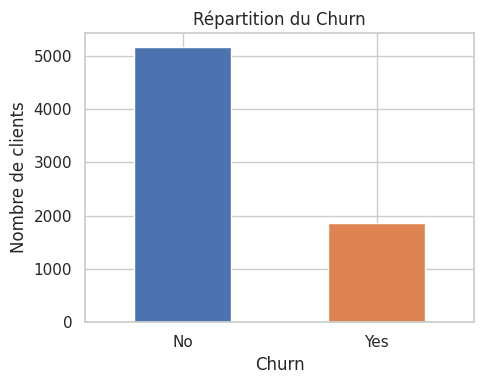

In [9]:
fig, ax = plt.subplots(figsize=(5,4))
df_clean['Churn'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title("Répartition du Churn")
ax.set_xlabel("Churn")
ax.set_ylabel("Nombre de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/01_churn_distribution.png")
plt.show()


**📊 Analyse :** Ce graphe compte simplement le nombre de clients dans chaque catégorie (`No` = restés, `Yes` = partis).
On voit tout de suite que les deux barres n'ont pas la même hauteur : beaucoup plus de clients sont restés que partis (~73% vs ~27%).
**Pourquoi c'est important :** la cible est **déséquilibrée**. Si on entraînait un modèle "bête" qui prédit toujours "No", il aurait déjà ~73% de bonnes réponses (accuracy) sans avoir rien appris ! C'est pour ça qu'on ne se fiera pas qu'à l'accuracy plus tard, mais aussi au rappel/F1/AUC, et qu'on utilisera `class_weight='balanced'` dans les modèles.


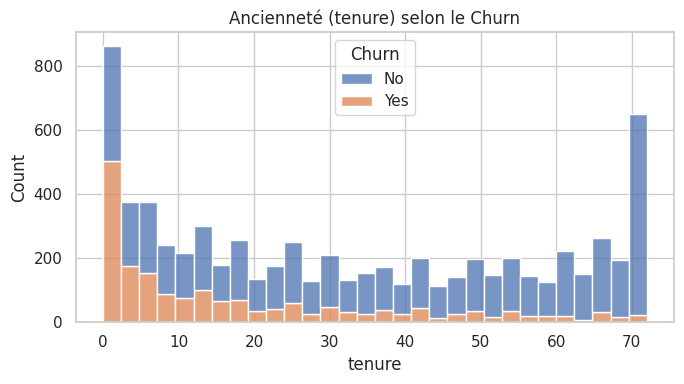

In [10]:
fig, ax = plt.subplots(figsize=(7,4))
sns.histplot(data=df_clean, x='tenure', hue='Churn', multiple='stack', bins=30, ax=ax, palette=['#4C72B0', '#DD8452'])
ax.set_title("Ancienneté (tenure) selon le Churn")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/02_tenure_vs_churn.png")
plt.show()


**📊 Analyse :** Histogramme empilé — chaque barre regroupe les clients par tranche d'ancienneté (`tenure`, en mois), coloriée selon qu'ils sont partis (orange) ou restés (bleu). La hauteur totale = nombre de clients dans cette tranche ; la partie orange = combien ont churné.
On voit que la partie orange est **énorme au tout début** (0-2 mois) et **rétrécit progressivement** à mesure que l'ancienneté augmente, jusqu'à devenir minuscule après 60 mois.
**Ce que ça veut dire :** le churn est concentré chez les **clients récents**. Plus un client reste longtemps, moins il a de chances de partir. → Piste d'action métier : renforcer le suivi/l'accompagnement dans les premiers mois d'abonnement.


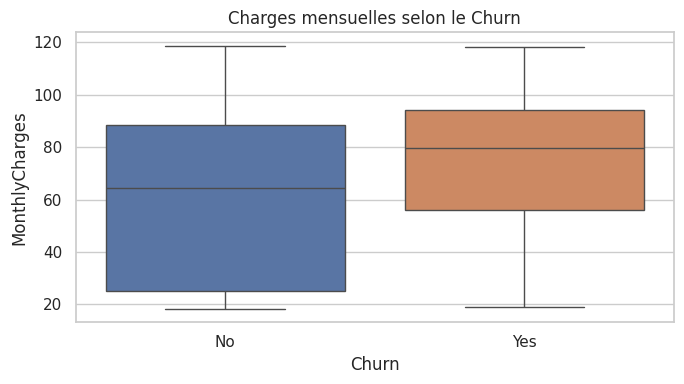

In [11]:
fig, ax = plt.subplots(figsize=(7,4))
sns.boxplot(data=df_clean, x='Churn', y='MonthlyCharges', hue='Churn', palette=['#4C72B0', '#DD8452'], legend=False, ax=ax)
ax.set_title("Charges mensuelles selon le Churn")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/03_monthlycharges_vs_churn.png")
plt.show()


**📊 Analyse :** Boxplot — chaque boîte résume la distribution des charges mensuelles pour un groupe (No / Yes). Le trait au milieu = la médiane, la boîte = les 50% de clients "du milieu".
La boîte **orange (Yes)** est **plus haute** que la bleue (No) : la médiane des clients qui partent est autour de 80€, contre ~65€ pour ceux qui restent.
**Ce que ça veut dire :** les clients qui paient plus cher chaque mois ont tendance à churner davantage. Attention : ça ne veut pas forcément dire que le prix est la *cause* — ça peut être lié au type de service (ex : la fibre optique, plus chère, churne aussi plus — voir graphe 5).


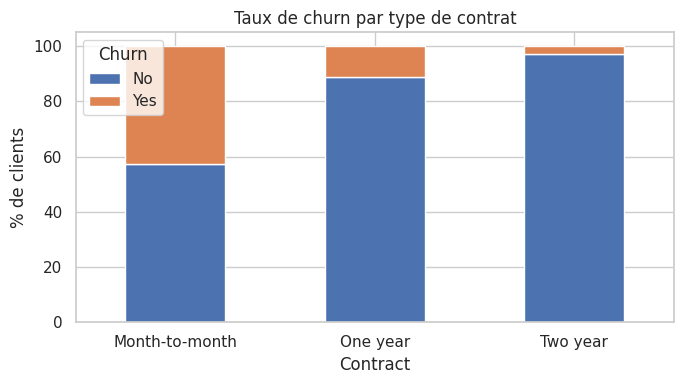

In [12]:
fig, ax = plt.subplots(figsize=(7,4))
churn_by_contract = pd.crosstab(df_clean['Contract'], df_clean['Churn'], normalize='index') * 100
churn_by_contract.plot(kind='bar', stacked=True, color=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title("Taux de churn par type de contrat")
ax.set_ylabel("% de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/04_churn_by_contract.png")
plt.show()


**📊 Analyse :** Ici chaque barre = 100% des clients d'un type de contrat (`normalize='index'` transforme les comptes en pourcentages), donc on compare des **proportions**, pas des nombres bruts — ça évite le piège du graphe précédent (une grande barre n'est pas forcément "plus de churn en %").
On voit que la barre `Month-to-month` (mensuel) a une part orange **beaucoup plus grande** que `One year` ou `Two year`, où l'orange est presque invisible.
**Ce que ça veut dire :** le type de contrat est un facteur très fort du churn. Un client sans engagement (mensuel) peut partir à tout moment et le fait beaucoup plus souvent — c'est même le facteur le plus déterminant qu'on retrouvera plus tard dans l'importance des variables du Random Forest.


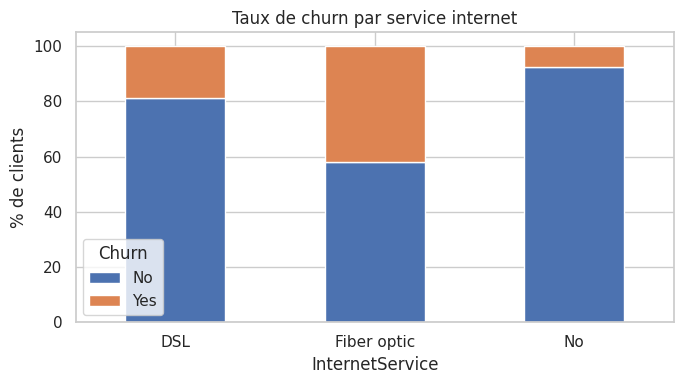

In [13]:
fig, ax = plt.subplots(figsize=(7,4))
churn_by_internet = pd.crosstab(df_clean['InternetService'], df_clean['Churn'], normalize='index') * 100
churn_by_internet.plot(kind='bar', stacked=True, color=['#4C72B0', '#DD8452'], ax=ax)
ax.set_title("Taux de churn par service internet")
ax.set_ylabel("% de clients")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/05_churn_by_internet.png")
plt.show()


**📊 Analyse :** Même principe que le graphe précédent (barres normalisées en %), mais par type de service internet.
Les clients **Fiber optic** ont une part orange nettement plus grande que **DSL**, et les clients **sans internet du tout** (`No`) churnent très peu.
**Ce que ça veut dire :** avoir la fibre est associé à plus de churn — peut-être parce que la fibre coûte plus cher (cohérent avec le graphe des charges mensuelles), ou parce que ces clients sont plus exigeants/technophiles et changent plus facilement de fournisseur. À creuser, mais c'est un signal fort.


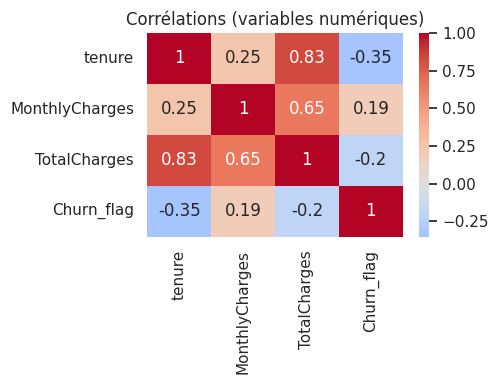

In [14]:
# Matrice de corrélation des variables numériques
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn_flag']
fig, ax = plt.subplots(figsize=(5,4))
sns.heatmap(df_clean[num_cols].corr(), annot=True, cmap='coolwarm', center=0, ax=ax)
ax.set_title("Corrélations (variables numériques)")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/06_correlation_heatmap.png")
plt.show()


**📊 Analyse :** La heatmap affiche la corrélation (entre -1 et 1) entre chaque paire de variables numériques. Plus une case est rouge foncé, plus la relation est positive forte ; plus elle est bleu foncé, plus elle est négative forte ; proche de 0 = pas de lien linéaire.
On voit que `Churn_flag` est **négativement corrélée avec `tenure`** (~-0.35) et **positivement corrélée avec `MonthlyCharges`** (~+0.19).
**Ce que ça veut dire :** ça confirme numériquement ce qu'on a vu visuellement dans les graphes 2 et 3 — plus l'ancienneté est grande, moins on churn ; plus la charge mensuelle est élevée, plus on churn. On voit aussi que `tenure` et `TotalCharges` sont très corrélées entre elles (logique : plus on reste longtemps, plus le total facturé cumule) — un point à garder en tête pour l'interprétation des modèles.


**Premiers constats :**
- La cible est déséquilibrée (~73% "No" / ~27% "Yes") → il faudra en tenir compte dans l'évaluation (pas se fier à l'accuracy seule).
- Les clients qui résilient ont en moyenne une **ancienneté plus faible** et des **charges mensuelles plus élevées**.
- Le **contrat mensuel (Month-to-month)** a un taux de churn bien plus élevé que les contrats 1 an / 2 ans.
- Les clients **Fiber optic** résilient davantage que les clients DSL ou sans internet.


## 4. Prétraitement

- Séparation features / cible.
- Encodage des variables catégorielles (one-hot encoding).
- Split train/test stratifié (pour garder la même proportion de churn).
- Standardisation des variables numériques (utile pour la régression logistique).


In [15]:
target = 'Churn_flag'
features = df_clean.drop(columns=['Churn', 'Churn_flag'])

categorical_cols = features.select_dtypes(include='object').columns.tolist()
numeric_cols = features.select_dtypes(exclude='object').columns.tolist()

print("Colonnes catégorielles :", categorical_cols)
print("Colonnes numériques :", numeric_cols)


Colonnes catégorielles : ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Colonnes numériques : ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


/tmp/ipykernel_104/2008900168.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = features.select_dtypes(include='object').columns.tolist()


In [16]:
features_encoded = pd.get_dummies(features, columns=categorical_cols, drop_first=True)
print("Shape après encodage :", features_encoded.shape)
features_encoded.head()


Shape après encodage : (7043, 30)


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    features_encoded, df_clean[target],
    test_size=0.2, random_state=RANDOM_STATE, stratify=df_clean[target]
)

print("Train :", X_train.shape, "| Test :", X_test.shape)
print("Taux de churn train :", y_train.mean().round(3), "| test :", y_test.mean().round(3))


Train : (5634, 30) | Test : (1409, 30)
Taux de churn train : 0.265 | test : 0.265


In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 5. Modèle : Régression Logistique

Modèle linéaire simple, interprétable, souvent utilisé comme baseline pour des problèmes de classification binaire type churn.


In [19]:
log_reg = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_proba_lr = log_reg.predict_proba(X_test_scaled)[:, 1]

print(classification_report(y_test, y_pred_lr, target_names=['No Churn', 'Churn']))


              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.51      0.79      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



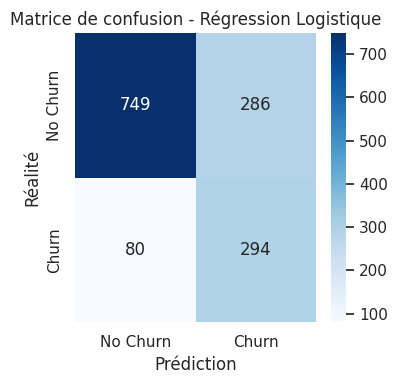

In [20]:
fig, ax = plt.subplots(figsize=(4,4))
cm = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'], ax=ax)
ax.set_title("Matrice de confusion - Régression Logistique")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/07_confusion_matrix_logreg.png")
plt.show()


**📊 Analyse :** La matrice de confusion compare les prédictions du modèle à la réalité sur le jeu de test. Les lignes = la vraie classe, les colonnes = ce que le modèle a prédit.
- **Diagonale (haut-gauche + bas-droite)** = bonnes prédictions
- **Hors diagonale** = erreurs

En haut à droite : des clients qui sont réellement restés mais que le modèle a prédit comme "Churn" (faux positifs). En bas à gauche : des clients qui ont réellement churné mais que le modèle a prédit "No Churn" (faux négatifs — les plus coûteux en général, car on rate un client à risque qu'on aurait pu essayer de retenir).
**Ce que ça veut dire :** grâce à `class_weight='balanced'`, le modèle détecte pas mal de vrais churners (peu de faux négatifs), mais au prix de plusieurs faux positifs — c'est le compromis précision/rappel qu'on retrouve dans le tableau de métriques juste avant.


## 6. Modèle : Random Forest

Modèle d'ensemble à base d'arbres, capable de capturer des relations non-linéaires et des interactions entre variables, souvent plus performant qu'une régression logistique sur ce type de données tabulaires.


In [21]:
rf = RandomForestClassifier(
    n_estimators=300, max_depth=8, random_state=RANDOM_STATE,
    class_weight='balanced', n_jobs=-1
)
rf.fit(X_train, y_train)  # Random Forest n'a pas besoin de standardisation

y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))


              precision    recall  f1-score   support

    No Churn       0.91      0.75      0.82      1035
       Churn       0.53      0.78      0.63       374

    accuracy                           0.76      1409
   macro avg       0.72      0.77      0.73      1409
weighted avg       0.81      0.76      0.77      1409



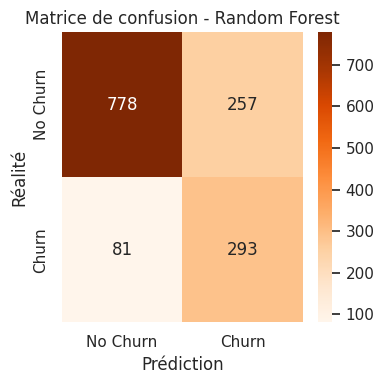

In [22]:
fig, ax = plt.subplots(figsize=(4,4))
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'], ax=ax)
ax.set_title("Matrice de confusion - Random Forest")
ax.set_xlabel("Prédiction")
ax.set_ylabel("Réalité")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/08_confusion_matrix_rf.png")
plt.show()


**📊 Analyse :** Même lecture que la matrice précédente, mais pour le Random Forest — ça permet de comparer visuellement les deux modèles case par case.
**Ce que ça veut dire :** si les nombres sur la diagonale sont plus élevés ici que pour la régression logistique, ça confirme que le Random Forest se trompe un peu moins globalement (cohérent avec sa meilleure accuracy dans le tableau de comparaison).


## 7. Comparaison des modèles

On compare les deux modèles sur plusieurs métriques (l'accuracy seule est trompeuse vu le déséquilibre de classes) et via la courbe ROC.


In [23]:
def get_metrics(name, y_true, y_pred, y_proba):
    return {
        'Modèle': name,
        'Accuracy': accuracy_score(y_true, y_pred),
        'Précision': precision_score(y_true, y_pred),
        'Rappel (Recall)': recall_score(y_true, y_pred),
        'F1-score': f1_score(y_true, y_pred),
        'ROC AUC': roc_auc_score(y_true, y_proba),
    }

results = pd.DataFrame([
    get_metrics("Régression Logistique", y_test, y_pred_lr, y_proba_lr),
    get_metrics("Random Forest", y_test, y_pred_rf, y_proba_rf),
]).set_index('Modèle').round(3)

results


,Accuracy,Précision,Rappel (Recall),F1-score,ROC AUC
Modèle,,,,,
Régression Logistique,0.74,0.507,0.786,0.616,0.841
Random Forest,0.76,0.533,0.783,0.634,0.844


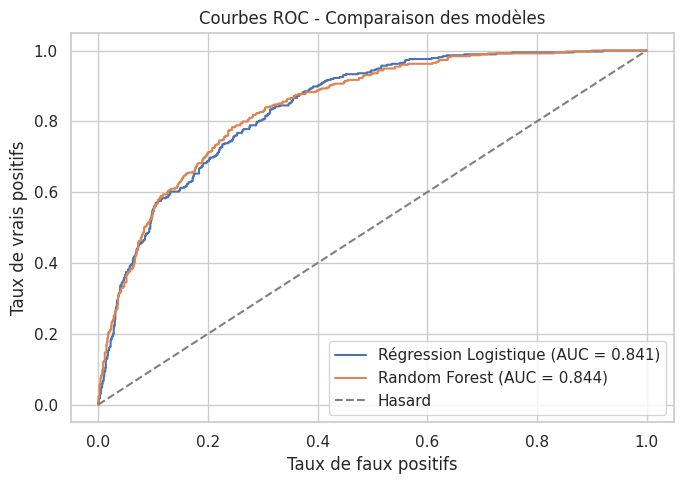

In [24]:
fig, ax = plt.subplots(figsize=(7,5))
for name, y_proba in [("Régression Logistique", y_proba_lr), ("Random Forest", y_proba_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    ax.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Hasard')
ax.set_xlabel("Taux de faux positifs")
ax.set_ylabel("Taux de vrais positifs")
ax.set_title("Courbes ROC - Comparaison des modèles")
ax.legend()
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/09_roc_curves.png")
plt.show()


**📊 Analyse :** La courbe ROC montre, pour tous les seuils de décision possibles (pas seulement 0.5), le compromis entre le taux de vrais positifs (axe Y, "on détecte bien les churners") et le taux de faux positifs (axe X, "on se trompe sur des clients fidèles"). La ligne pointillée grise = un modèle qui prédit au hasard.
Plus une courbe est **proche du coin haut-gauche**, meilleur est le modèle. L'**AUC** (Area Under the Curve, entre 0.5 et 1) résume ça en un seul chiffre : 1 = parfait, 0.5 = hasard.
**Ce que ça veut dire :** les deux courbes sont largement au-dessus de la diagonale (AUC ~0.84 pour les deux), donc les deux modèles séparent bien mieux que le hasard les clients qui vont churner de ceux qui restent. Le Random Forest est très légèrement au-dessus, confirmant son léger avantage.


## 8. Interprétation

### Régression Logistique : coefficients
Les coefficients (sur variables standardisées) indiquent le sens et la force de l'effet de chaque variable sur la probabilité de churn.


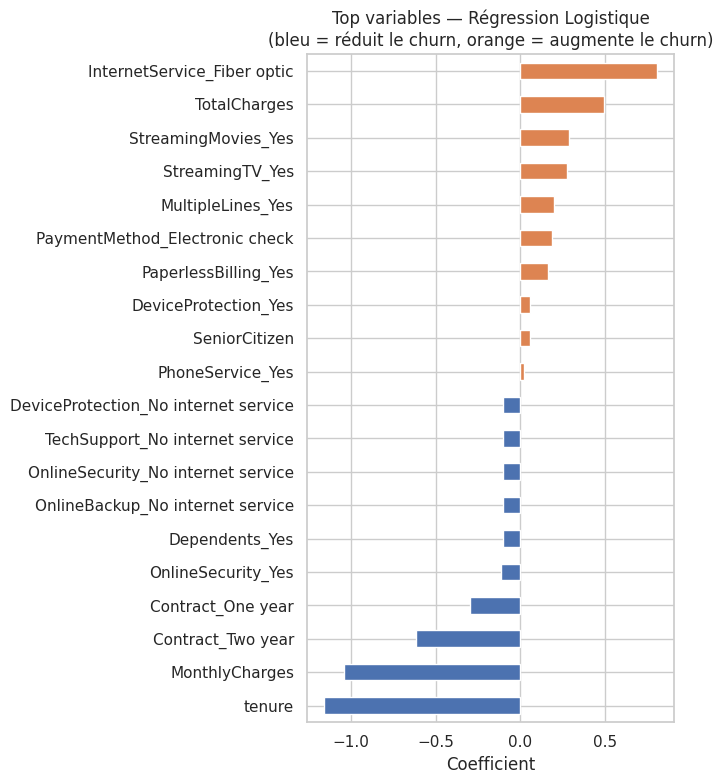

In [25]:
coefs = pd.Series(log_reg.coef_[0], index=X_train.columns).sort_values()

fig, ax = plt.subplots(figsize=(7,8))
top_coefs = pd.concat([coefs.head(10), coefs.tail(10)])
colors = ['#4C72B0' if v < 0 else '#DD8452' for v in top_coefs.values]
top_coefs.plot(kind='barh', color=colors, ax=ax)
ax.set_title("Top variables — Régression Logistique\n(bleu = réduit le churn, orange = augmente le churn)")
ax.set_xlabel("Coefficient")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/10_logreg_coefficients.png")
plt.show()


**📊 Analyse :** Chaque barre = le coefficient d'une variable (sur données standardisées, donc comparables entre elles). Une barre **orange** (coefficient positif) veut dire "quand cette variable augmente/est présente, la probabilité de churn augmente" ; une barre **bleue** (négative) veut dire l'inverse.
**Ce que ça veut dire :** ça donne une lecture directe et interprétable — par exemple avoir un `Contract_Two year` (bleu, gros coefficient négatif) protège fortement contre le churn, alors que `Contract_Month-to-month` ou `InternetService_Fiber optic` (orange) l'augmentent. C'est l'avantage principal de la régression logistique par rapport au Random Forest : on peut dire précisément *dans quel sens* chaque variable agit, pas juste "elle compte".


### Random Forest : importance des variables


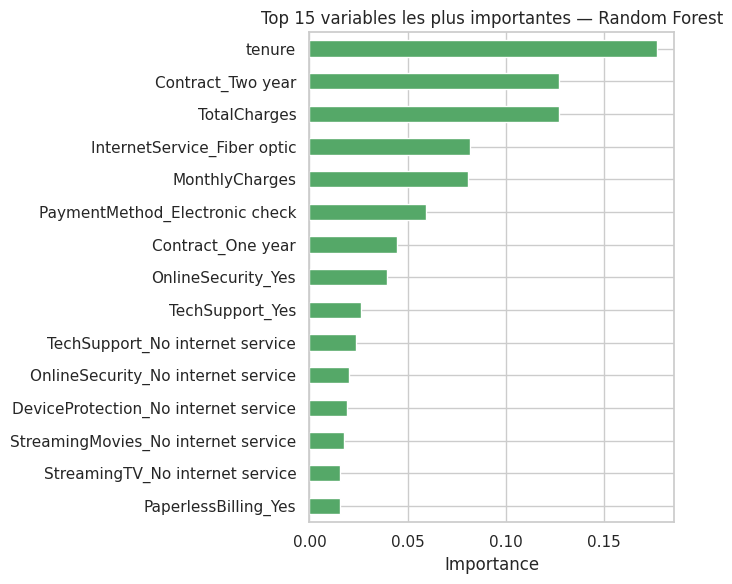

In [26]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(7,6))
importances.sort_values().plot(kind='barh', color='#55A868', ax=ax)
ax.set_title("Top 15 variables les plus importantes — Random Forest")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(f"{FIG_DIR}/11_rf_feature_importance.png")
plt.show()


**📊 Analyse :** Chaque barre = à quel point le Random Forest s'est appuyé sur cette variable pour faire ses prédictions (peu importe le sens, juste l'importance). Contrairement au graphe précédent, il n'y a **pas de couleur bleu/orange** : on ne sait pas *dans quel sens* la variable joue, juste *combien* elle compte.
**Ce que ça veut dire :** on retrouve en haut `tenure`, `MonthlyCharges`, `TotalCharges` et le type de contrat — cohérent avec tout ce qu'on a vu en EDA. C'est un bon moyen de vérifier que le modèle "a appris" des choses qui ont du sens métier, et pas des variables bizarres sans rapport.


### Résumé des enseignements métier

- **Le type de contrat est le facteur le plus déterminant** : les clients en contrat mensuel (`Month-to-month`) résilient beaucoup plus que ceux engagés 1 ou 2 ans. → Pousser les clients vers des contrats engageants (offres, remises à l'engagement).
- **L'ancienneté (`tenure`) faible est associée à un churn élevé** : les nouveaux clients sont les plus fragiles. → Programme d'accueil / suivi renforcé les premiers mois.
- **Les services de sécurité/support (`OnlineSecurity`, `TechSupport`) réduisent le churn** quand ils sont souscrits. → Les proposer activement peut fidéliser.
- **Des charges mensuelles élevées et la fibre optique (`Fiber optic`)** sont associées à plus de churn, peut-être en raison du prix ou de problèmes de qualité perçue.
- Le **Random Forest surpasse légèrement la régression logistique** sur l'AUC (voir tableau de comparaison), au prix d'une interprétabilité un peu moindre — la régression logistique reste utile pour communiquer simplement l'effet de chaque variable.

### Limites et pistes d'amélioration
- Essayer d'autres modèles (Gradient Boosting / XGBoost).
- Optimiser les hyperparamètres (GridSearchCV / RandomizedSearchCV).
- Traiter le déséquilibre de classes avec du SMOTE en plus de `class_weight='balanced'`.
- Analyser le coût métier (coût d'un faux négatif vs faux positif) pour choisir le seuil de décision optimal plutôt que 0.5.
